In [1]:
features_dir = '/Users/kesiyun/Desktop/Thesis/github/features/01SF_sw' 
extra_features_dir = '/Users/kesiyun/Desktop/Thesis/github/features/01SF_sw_aug'
split_path = '/Users/kesiyun/Desktop/Thesis/github/config/00full_video_split_5s.json'
json_path = '/Users/kesiyun/Desktop/Thesis/github/config/00sequenceresult.json'


import os
import json

import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.utils.data import TensorDataset, random_split

import ast
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, f1_score
import numpy as np


# Utility functions
def read_json(path):
    with open(path, 'r') as f:
        return json.load(f)



def print_loader_metadata(train_loader, test_loader):
    def get_loader_stats(loader, name):
        label_counts = {}
        feature_shapes = {}
        total_samples = 0

        for batch in loader:
            features, labels = batch
            total_samples += len(labels)

            for feature, label in zip(features, labels):
                label_val = label.item()
                label_counts[label_val] = label_counts.get(label_val, 0) + 1

                shape = tuple(feature.shape)
                feature_shapes[shape] = feature_shapes.get(shape, 0) + 1

        print(f"\n{name} Loader:")
        print(f"  Total samples: {total_samples}")
        print(f"  Total batches (batch_size={loader.batch_size}): {len(loader)}")
        print(f"  Feature shape(s):")
        for shape, count in feature_shapes.items():
            print(f"    Shape {shape}: {count} samples")
        print(f"  Label distribution:")
        for label, count in sorted(label_counts.items()):
            print(f"    Label {label}: {count} samples")

    get_loader_stats(train_loader, "Training")
    get_loader_stats(test_loader, "Testing")




In [2]:
#prepare the data

#load the data from: 1- 00SF, 2- 01SF_sw

#features_dir = ''
#split_path = ''

dataset_split=read_json(split_path)

training_split=dataset_split['training_set']
test_split=dataset_split['testing_set']
#print(training_split)
#print(test_split)

train_features = []
train_labels = []
for video_name in training_split:
    feature_list_load_1 = torch.load(os.path.join(features_dir, video_name + '.pt'))
    for i in range(len(feature_list_load_1)):
        feature_this = feature_list_load_1[i][0]  # shape: [1, 2304]
        label_this = feature_list_load_1[i][1]    # assuming label is stored here as an integer
        train_features.append(feature_this)
        train_labels.append(label_this)
    print(video_name, 'added to training')
# Convert to tensors
X_train = torch.cat(train_features, dim=0)  # shape: [num_samples, 2304]
y_train = torch.tensor(train_labels).float().unsqueeze(1)  # shape: [num_samples, 1]

test_features = []
test_labels = []
for video_name in test_split:
    feature_list_load_1 = torch.load(os.path.join(features_dir, video_name + '.pt'))
    for i in range(len(feature_list_load_1)):
        feature_this = feature_list_load_1[i][0]  # shape: [1, 2304]
        label_this = feature_list_load_1[i][1]    # assuming label is stored here as an integer
        test_features.append(feature_this)
        test_labels.append(label_this)
    print(video_name, 'added to testing')
# Convert to tensors
X_test = torch.cat(test_features, dim=0)  # shape: [num_samples, 2304]
y_test = torch.tensor(test_labels).float().unsqueeze(1)  # shape: [num_samples, 1]





1A added to training
1B added to training
1C added to training
1D added to training
1E added to training
1F added to training
2A added to training
3A added to training
3B added to training
3C added to training
3D added to training
4B added to training
4D added to training
4F added to training
5A added to training
6A added to training
6B added to training
6C added to training
6D added to training
7A added to training
8A added to training
8B added to training
9A added to training
10A added to training
10B added to training
10C added to training
11A added to training
11B added to training
11C added to training
11D added to training
12A added to training
13A added to training
14A added to training
14B added to training
14C added to training
14D added to training
14E added to training
15A added to training
15B added to training
15C added to training
15D added to training
17A added to training
17B added to training
17C added to training
17D added to training
17E added to training
17F added t

In [3]:
#Used in Original, weighted loss
# Set a fixed random seed
seed = 3407
generator = torch.Generator().manual_seed(seed)

# ----- Virtual Split from Training Data -----
train_size = int(0.8 * len(X_train))
val_size = len(X_train) - train_size
train_dataset, val_dataset = random_split(
    TensorDataset(X_train, y_train),
    [train_size, val_size],
    generator=generator
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=32)

print_loader_metadata(train_loader, test_loader)


import random
import numpy as np
import torch





Training Loader:
  Total samples: 28837
  Total batches (batch_size=32): 902
  Feature shape(s):
    Shape (2304,): 28837 samples
  Label distribution:
    Label 0.0: 28148 samples
    Label 1.0: 689 samples

Testing Loader:
  Total samples: 8172
  Total batches (batch_size=32): 256
  Feature shape(s):
    Shape (2304,): 8172 samples
  Label distribution:
    Label 0.0: 8052 samples
    Label 1.0: 120 samples


Epoch 1, Train Loss: 1.0817, Val Loss: 0.8552, Val F1 (class 1): 0.2100
Epoch 2, Train Loss: 0.8520, Val Loss: 0.7719, Val F1 (class 1): 0.2332
Epoch 3, Train Loss: 0.7567, Val Loss: 0.8197, Val F1 (class 1): 0.3423
Epoch 4, Train Loss: 0.7131, Val Loss: 0.6755, Val F1 (class 1): 0.2588
Epoch 5, Train Loss: 0.6697, Val Loss: 0.6921, Val F1 (class 1): 0.2294
Epoch 6, Train Loss: 0.6408, Val Loss: 0.6473, Val F1 (class 1): 0.2513
Epoch 7, Train Loss: 0.6082, Val Loss: 0.6665, Val F1 (class 1): 0.2160
Epoch 8, Train Loss: 0.5854, Val Loss: 0.6274, Val F1 (class 1): 0.3323
Epoch 9, Train Loss: 0.5719, Val Loss: 0.5973, Val F1 (class 1): 0.2886
Epoch 10, Train Loss: 0.5463, Val Loss: 0.6038, Val F1 (class 1): 0.3144
Epoch 11, Train Loss: 0.5286, Val Loss: 0.5896, Val F1 (class 1): 0.3040
Epoch 12, Train Loss: 0.5255, Val Loss: 0.6024, Val F1 (class 1): 0.2354
Epoch 13, Train Loss: 0.5120, Val Loss: 0.6287, Val F1 (class 1): 0.3617
Epoch 14, Train Loss: 0.4980, Val Loss: 0.5624, Val F1 (clas

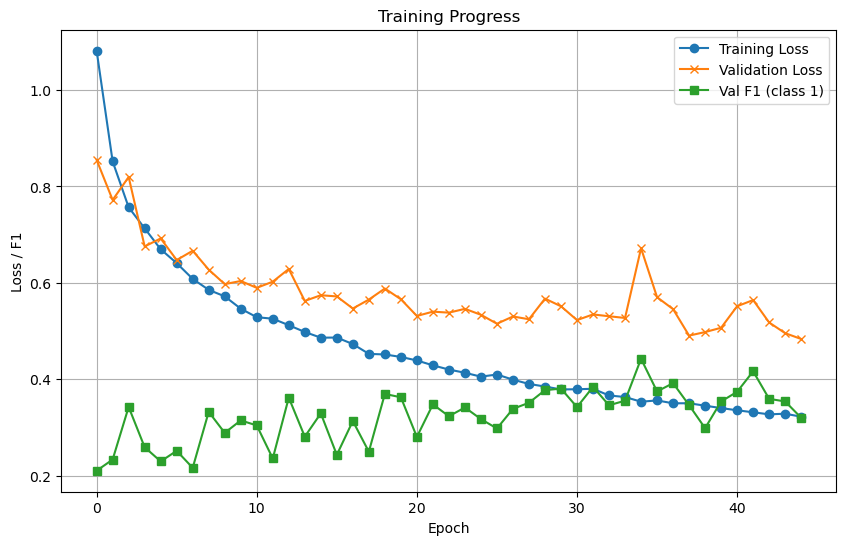

In [6]:
#weighted loss applied -sigmoid true

# Set fixed seed -reproducible
seed = 3407 #42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)  # if using multi-GPU

# Ensure deterministic behavior
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, f1_score


NEED_sigmoid_outout=True

# ----- Model Definition -----
class LinearClassifier(nn.Module):
    def __init__(self, input_dim):
        super(LinearClassifier, self).__init__()
        self.linear = nn.Linear(input_dim, 1)
        #self.sigmoid = nn.Sigmoid() # To ET: copilot says i need to move it to the eval under weigjted loss

    def forward(self, x):
        #return self.sigmoid(self.linear(x))
        return self.linear(x)  # No sigmoid here

# ----- Training Setup -----
input_dim = 2304
model = LinearClassifier(input_dim=input_dim)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

#criterion = nn.BCELoss()
# Compute pos_weight based on training label distribution
pos_weight = torch.tensor([26485 / 608], device=device)  # ratio of majority to minority
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

###Validation using f1
train_losses = []
val_losses = []
val_f1_scores = []

# Early stopping parameters
manual_patience = 10
best_val_f1 = 0.0
epochs_no_improve = 0
max_epochs = 500

# Demonstration flag
demonstrate_early_stopping = False  # True

# Track best model
best_model_state = None
best_epoch = 0

# ----- Training Loop -----
for epoch in range(max_epochs):
    model.train()
    total_loss = 0
    for features, labels in train_loader:
        features, labels = features.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(features)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_train_loss = total_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Validation
    model.eval()
    val_loss = 0.0
    val_preds = []
    val_targets = []

    with torch.no_grad():
        for val_features, val_labels in val_loader:
            val_features, val_labels = val_features.to(device), val_labels.to(device)
            val_outputs = model(val_features)
            val_loss += criterion(val_outputs, val_labels).item()
            val_preds.extend((val_outputs > 0.5).float().cpu().numpy())
            val_targets.extend(val_labels.cpu().numpy())

    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    val_f1_C = f1_score(val_targets, val_preds, pos_label=1)
    val_f1_scores.append(val_f1_C)

    print(f"Epoch {epoch+1}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}, Val F1 (class 1): {val_f1_C:.4f}")

    # Early stopping logic based on F1-score of class 1
    if val_f1_C > best_val_f1:
        best_val_f1 = val_f1_C
        best_model_state = model.state_dict()
        best_epoch = epoch
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= manual_patience:
            print(f"Early stopping triggered at epoch {epoch+1} based on F1-score of class 1, used best model on {best_epoch} epoch ")
            if not demonstrate_early_stopping:
                break
            if val_f1_C < 0.8 * best_val_f1:
                print("Validation F1-score dropped significantly. Stopping training.")
                break

# Restore best model for evaluation
model.load_state_dict(best_model_state)

# ----- Plot Loss Curves -----
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss', marker='o')
plt.plot(val_losses, label='Validation Loss', marker='x')
plt.plot(val_f1_scores, label='Val F1 (class 1)', marker='s')
if demonstrate_early_stopping:
    plt.axvline(x=best_epoch, color='r', linestyle='--', label='Early Stop Point')
plt.title('Training Progress')
plt.xlabel('Epoch')
plt.ylabel('Loss / F1')
plt.legend()
plt.grid(True)
plt.savefig("loss_curves.png")

# ----- Final Evaluation on Test Set -----
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for features, labels in test_loader:
        features = features.to(device)
        if NEED_sigmoid_outout:
            outputs = torch.sigmoid(model(features)) # sigmoid outout
        else:
            outputs = model(features)# no sigmoid for this model
        preds = (outputs > 0.5).float().cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

# Convert to flat arrays
all_preds = torch.tensor(all_preds).view(-1).numpy()
all_labels = torch.tensor(all_labels).view(-1).numpy()

# ----- Manual TP, FN, FP for class 'C' (label 1) -----
TP_c = ((all_preds == 1) & (all_labels == 1)).sum()
FN_c = ((all_preds == 0) & (all_labels == 1)).sum()
FP_c = ((all_preds == 1) & (all_labels == 0)).sum()

# ----- Metrics -----
precision_C = precision_score(all_labels, all_preds, pos_label=1)
recall_C = recall_score(all_labels, all_preds, pos_label=1)
f1_C = f1_score(all_labels, all_preds, pos_label=1)

accuracy = accuracy_score(all_labels, all_preds)
macro_precision = precision_score(all_labels, all_preds, average='macro')
macro_f1 = f1_score(all_labels, all_preds, average='macro')

# ----- Output -----
print("\n--- Detailed Evaluation on Test Set ---")
print(f"True Positives (C): {TP_c}")
print(f"False Positives (C): {FP_c}")
print(f"False Negatives (C): {FN_c}")
print(f"Precision (C): {precision_C:.4f}")
print(f"Recall (C): {recall_C:.4f}")
print(f"F1 Score (C): {f1_C:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Macro Precision: {macro_precision:.4f}")
print(f"Macro F1: {macro_f1:.4f}")

Using Focal Loss with alpha=0.25, gamma=6
Epoch 1, Train Loss: 0.0006, Val Loss: 0.0004, Val F1 (class 1): 0.0258
Epoch 2, Train Loss: 0.0004, Val Loss: 0.0004, Val F1 (class 1): 0.0258
Epoch 3, Train Loss: 0.0004, Val Loss: 0.0004, Val F1 (class 1): 0.0258
Epoch 4, Train Loss: 0.0004, Val Loss: 0.0005, Val F1 (class 1): 0.0380
Epoch 5, Train Loss: 0.0004, Val Loss: 0.0004, Val F1 (class 1): 0.1734
Epoch 6, Train Loss: 0.0004, Val Loss: 0.0004, Val F1 (class 1): 0.0629
Epoch 7, Train Loss: 0.0003, Val Loss: 0.0003, Val F1 (class 1): 0.1637
Epoch 8, Train Loss: 0.0004, Val Loss: 0.0004, Val F1 (class 1): 0.0745
Epoch 9, Train Loss: 0.0003, Val Loss: 0.0003, Val F1 (class 1): 0.1557
Epoch 10, Train Loss: 0.0003, Val Loss: 0.0004, Val F1 (class 1): 0.0745
Epoch 11, Train Loss: 0.0003, Val Loss: 0.0003, Val F1 (class 1): 0.0750
Epoch 12, Train Loss: 0.0003, Val Loss: 0.0003, Val F1 (class 1): 0.1333
Epoch 13, Train Loss: 0.0003, Val Loss: 0.0004, Val F1 (class 1): 0.0506
Epoch 14, Train Lo

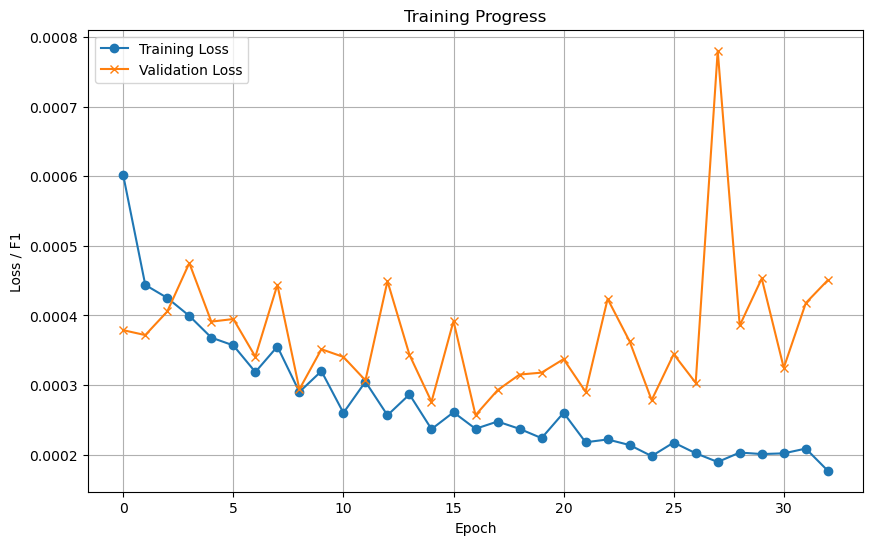

In [8]:
#Focal loss applied -sigmoid true

# Tunable focal loss parameters
alpha = 0.25 #0.25
gamma = 6 #2


# Set fixed seed -reproducible
seed = 3407 #42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)  # if using multi-GPU

# Ensure deterministic behavior
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, f1_score


NEED_sigmoid_outout=True


# ----- Focal Loss Definition -----
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.bce = nn.BCEWithLogitsLoss(reduction='none')

    def forward(self, inputs, targets):
        BCE_loss = self.bce(inputs, targets)
        pt = torch.exp(-BCE_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * BCE_loss
        return focal_loss.mean()

# ----- Model Definition -----
class LinearClassifier(nn.Module):
    def __init__(self, input_dim):
        super(LinearClassifier, self).__init__()
        self.linear = nn.Linear(input_dim, 1)
        #self.sigmoid = nn.Sigmoid() # To ET: dr copilot says i need to move it to the eval under weigjted loss

    def forward(self, x):
        #return self.sigmoid(self.linear(x))
        return self.linear(x)  # No sigmoid here

# ----- Training Setup -----
input_dim = 2304
model = LinearClassifier(input_dim=input_dim)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)


criterion = FocalLoss(alpha=alpha, gamma=gamma)
print(f"Using Focal Loss with alpha={alpha}, gamma={gamma}")

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

###Validation using f1
train_losses = []
val_losses = []
val_f1_scores = []

# Early stopping parameters
manual_patience = 10
best_val_f1 = 0.0
epochs_no_improve = 0
max_epochs = 500

# Demonstration flag
demonstrate_early_stopping = False  # True

# Track best model
best_model_state = None
best_epoch = 0

# ----- Training Loop -----
for epoch in range(max_epochs):
    model.train()
    total_loss = 0
    for features, labels in train_loader:
        features, labels = features.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(features)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_train_loss = total_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Validation
    model.eval()
    val_loss = 0.0
    val_preds = []
    val_targets = []

    with torch.no_grad():
        for val_features, val_labels in val_loader:
            val_features, val_labels = val_features.to(device), val_labels.to(device)
            val_outputs = model(val_features)
            val_loss += criterion(val_outputs, val_labels).item()
            val_preds.extend((val_outputs > 0.5).float().cpu().numpy())
            val_targets.extend(val_labels.cpu().numpy())

    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    val_f1_C = f1_score(val_targets, val_preds, pos_label=1)
    val_f1_scores.append(val_f1_C)

    print(f"Epoch {epoch+1}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}, Val F1 (class 1): {val_f1_C:.4f}")

    # Early stopping logic based on F1-score of class 1
    if val_f1_C > best_val_f1:
        best_val_f1 = val_f1_C
        best_model_state = model.state_dict()
        best_epoch = epoch
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= manual_patience:
            print(f"Early stopping triggered at epoch {epoch+1} based on F1-score of class 1, used best model on {best_epoch} epoch ")
            if not demonstrate_early_stopping:
                break
            if val_f1_C < 0.8 * best_val_f1:
                print("Validation F1-score dropped significantly. Stopping training.")
                break

# Restore best model for evaluation
model.load_state_dict(best_model_state)

# ----- Plot Loss Curves -----
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss', marker='o')
plt.plot(val_losses, label='Validation Loss', marker='x')
#plt.plot(val_f1_scores, label='Val F1 (class 1)', marker='s')
if demonstrate_early_stopping:
    plt.axvline(x=best_epoch, color='r', linestyle='--', label='Early Stop Point')
plt.title('Training Progress')
plt.xlabel('Epoch')
plt.ylabel('Loss / F1')
plt.legend()
plt.grid(True)
plt.savefig("loss_curves.png")

# ----- Final Evaluation on Test Set -----
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for features, labels in test_loader:
        features = features.to(device)
        if NEED_sigmoid_outout:
            outputs = torch.sigmoid(model(features)) # sigmoid outout
        else:
            outputs = model(features)# no sigmoid for this model
        preds = (outputs > 0.5).float().cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

# Convert to flat arrays
all_preds = torch.tensor(all_preds).view(-1).numpy()
all_labels = torch.tensor(all_labels).view(-1).numpy()

# ----- Manual TP, FN, FP for class 'C' (label 1) -----
TP_c = ((all_preds == 1) & (all_labels == 1)).sum()
FN_c = ((all_preds == 0) & (all_labels == 1)).sum()
FP_c = ((all_preds == 1) & (all_labels == 0)).sum()

# ----- Metrics -----
precision_C = precision_score(all_labels, all_preds, pos_label=1)
recall_C = recall_score(all_labels, all_preds, pos_label=1)
f1_C = f1_score(all_labels, all_preds, pos_label=1)

accuracy = accuracy_score(all_labels, all_preds)
macro_precision = precision_score(all_labels, all_preds, average='macro')
macro_f1 = f1_score(all_labels, all_preds, average='macro')

# ----- Output -----
print("\n--- Detailed Evaluation on Test Set ---")
print(f"True Positives (C): {TP_c}")
print(f"False Positives (C): {FP_c}")
print(f"False Negatives (C): {FN_c}")
print(f"Precision (C): {precision_C:.4f}")
print(f"Recall (C): {recall_C:.4f}")
print(f"F1 Score (C): {f1_C:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Macro Precision: {macro_precision:.4f}")
print(f"Macro F1: {macro_f1:.4f}")

In [9]:
# Save the best model to file
save_path = "/Users/kesiyun/Desktop/00workspace/savedmodels/0/saved.pt"
torch.save(best_model_state, save_path)
print(f"Model saved to {save_path}")

Model saved to /Users/kesiyun/Desktop/00workspace/savedmodels/0/saved.pt
